# Mental Health in Tech Survey — Exploratory Data Analysis

## Stage 0: Problem Statement

### Why this analysis?

Mental health is an important topic in the workplace, but employees may not always feel comfortable discussing it or asking for help. This analysis looks at the mental health experiences of people working in the technology sector and explores the factors related to seeking treatment.

### Business Questions

This analysis focuses on three main questions:

1. How does treatment-seeking vary across different countries and US states?
2. Which personal and work-related factors are associated with treatment-seeking?
3. How do workplace support factors such as mental health benefits, care options, anonymity, wellness programs, and company size relate to treatment-seeking?

### Objective

The main objective is to explore the survey data, identify important patterns, and understand how personal and workplace factors are related to mental health treatment-seeking.

### About the Dataset

The dataset is from the **2014 Mental Health in Tech Survey** conducted by Open Sourcing Mental Illness. It contains information about employees' demographics, work environment, mental health, treatment, and workplace support.

The data is self-reported, so the findings show patterns in the survey responses and do not prove that one factor causes another.

### Stage 1.1 Data Overview

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('survey.csv')

print('Shape:', df.shape)
print('Survey period:', df['Timestamp'].min(), 'to', df['Timestamp'].max())

df.head()

Shape: (1259, 27)
Survey period: 2014-08-27 11:29:31 to 2016-02-01 23:04:31


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [6]:
df.isnull().sum()[df.isnull().sum()>0]

state              515
self_employed       18
work_interfere     264
comments          1095
dtype: int64

In [7]:
df['self_employed'] = df['self_employed'].fillna('Unknown')
df['work_interfere'] = df['work_interfere'].fillna('Not applicable')

### Stage 1.2 Data Assessment

In [9]:
df.isnull().sum()[df.isnull().sum()>0]

state        515
comments    1095
dtype: int64

In [10]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [11]:
df['Age'].describe()

count    1.259000e+03
mean     7.942815e+07
std      2.818299e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64

In [12]:
df['Age'].value_counts().sort_index()

Age
-1726            1
-29              1
-1               1
 5               1
 8               1
 11              1
 18              7
 19              9
 20              6
 21             16
 22             21
 23             51
 24             46
 25             61
 26             75
 27             71
 28             68
 29             85
 30             63
 31             67
 32             82
 33             70
 34             65
 35             55
 36             37
 37             43
 38             39
 39             33
 40             33
 41             21
 42             20
 43             28
 44             11
 45             12
 46             12
 47              2
 48              6
 49              4
 50              6
 51              5
 53              1
 54              3
 55              3
 56              4
 57              3
 58              1
 60              2
 61              1
 62              1
 65              1
 72              1
 329             1
 9999999

In [20]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 65)].copy()

In [21]:
df.shape

(1250, 28)

In [16]:
df['Age'].describe()

count    1250.000000
mean       32.044800
std         7.203076
min        18.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        65.000000
Name: Age, dtype: float64

### Age Data Cleaning

The `Age` column contained several invalid and extreme values, including negative ages and unusually large values. These values were identified as data-entry errors and were removed from the dataset.

For analysis, only respondents aged **18 to 65 years** were retained. After cleaning, the dataset contains **1,250 valid responses**.


In [17]:
df['Gender'].value_counts()

Gender
Male                                              612
male                                              204
Female                                            120
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Woman                                               3
Male                                                3
Female                                              2
Cis Male                                            2
Man                                                 2
Female (trans)                                      2
Malr                                                1
Trans woman                                         1
male leaning androgynous                            1
Cis Man              

In [22]:
def clean_gender(gender):
    gender = gender.strip().lower()

    if gender in ['male', 'm', 'man', 'cis male', 'cis man', 'male (cis)',
                  'male-ish', 'male leaning androgynous', 'mal', 'malr',
                  'msle', 'mail', 'maile', 'make', 'guy (-ish) ^_^',
                  'something kinda male?']:
        return 'Male'

    elif gender in ['female', 'f', 'woman', 'cis female', 'female (cis)',
                    'cis-female/femme', 'femail', 'femake']:
        return 'Female'

    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

In [23]:
df['Gender'].value_counts()

Gender
Male      989
Female    246
Other      15
Name: count, dtype: int64

### Gender Data Cleaning

The `Gender` column contained inconsistent entries, including different spellings, abbreviations, and variations such as `M`, `male`, `Man`, `F`, `female`, and `Woman`. To make the data consistent for analysis, these responses were standardized into three categories: **Male, Female, and Other**.

This standardization retained all respondents while making gender-based analysis easier and more consistent.


In [24]:
df['Country'].value_counts().head(15)

Country
United States     745
United Kingdom    184
Canada             72
Germany            45
Netherlands        27
Ireland            27
Australia          21
France             13
India              10
New Zealand         8
Italy               7
Poland              7
Sweden              7
Switzerland         7
South Africa        6
Name: count, dtype: int64

### Stage 2: Data Analysis

In [25]:
df['treatment'].value_counts()

treatment
Yes    631
No     619
Name: count, dtype: int64

In [26]:
df['family_history'].value_counts()

family_history
No     762
Yes    488
Name: count, dtype: int64

In [27]:
df['work_interfere'].value_counts()

work_interfere
Sometimes         464
Not applicable    262
Never             211
Rarely            173
Often             140
Name: count, dtype: int64

In [28]:
df['benefits'].value_counts()

benefits
Yes           472
Don't know    407
No            371
Name: count, dtype: int64

In [29]:
df['care_options'].value_counts()


care_options
No          499
Yes         439
Not sure    312
Name: count, dtype: int64

In [30]:
pd.crosstab(df['Country'], df['treatment'])

treatment,No,Yes
Country,,
Australia,8,13
Austria,3,0
Belgium,5,1
Bosnia and Herzegovina,1,0
Brazil,4,2
Bulgaria,2,2
Canada,35,37
China,1,0
Colombia,2,0


In [31]:
country_treatment = pd.crosstab(
    df['Country'],
    df['treatment'],
    normalize='index'
) * 100

country_treatment.sort_values('Yes', ascending=False).head(15)

treatment,No,Yes
Country,,
Japan,0.000000,100.000000
Croatia,0.000000,100.000000
Slovenia,0.000000,100.000000
Moldova,0.000000,100.000000
Denmark,0.000000,100.000000
South Africa,33.333333,66.666667
New Zealand,37.500000,62.500000
Australia,38.095238,61.904762
Poland,42.857143,57.142857


In [32]:
country_counts = df['Country'].value_counts()

countries_20plus = country_counts[country_counts >= 20].index

country_treatment_20plus = country_treatment.loc[countries_20plus]

country_treatment_20plus.sort_values('Yes', ascending=False)

treatment,No,Yes
Country,,
Australia,38.095238,61.904762
United States,45.369128,54.630872
Canada,48.611111,51.388889
United Kingdom,50.000000,50.000000
Ireland,51.851852,48.148148
Germany,53.333333,46.666667
Netherlands,66.666667,33.333333


In [33]:
country_summary = pd.DataFrame({
    'Respondents': country_counts[countries_20plus],
    'Treatment_Rate': country_treatment_20plus['Yes']
})

country_summary.sort_values('Treatment_Rate', ascending=False)

,Respondents,Treatment_Rate
Country,,
Australia,21,61.904762
United States,745,54.630872
Canada,72,51.388889
United Kingdom,184,50.000000
Ireland,27,48.148148
Germany,45,46.666667
Netherlands,27,33.333333


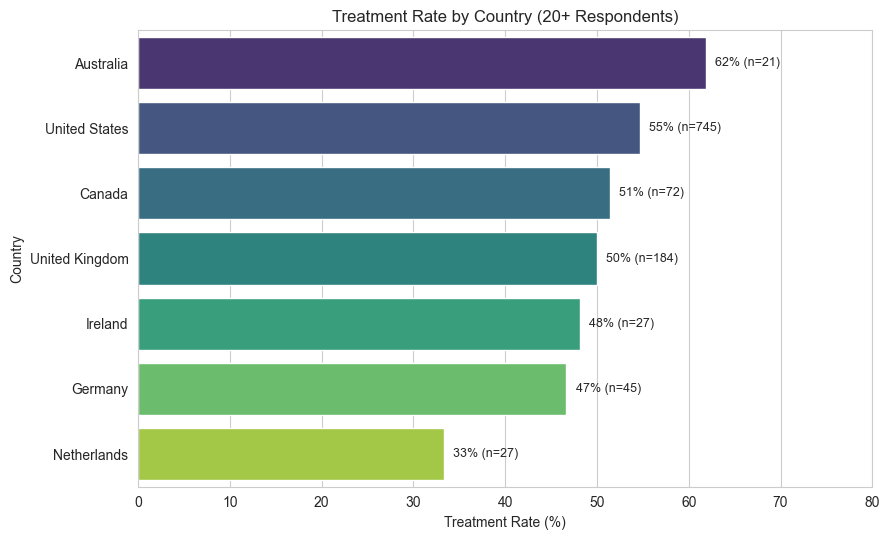

In [46]:
plt.figure(figsize=(9,5.5))

plot_data = country_summary.sort_values('Treatment_Rate', ascending=False)

ax = sns.barplot(
    x=plot_data['Treatment_Rate'],
    y=plot_data.index,
    palette='viridis'
)

for i, (v, n) in enumerate(zip(
    plot_data['Treatment_Rate'],
    plot_data['Respondents']
)):
    ax.text(v + 1, i, f'{v:.0f}% (n={n})', va='center', fontsize=9)

plt.title('Treatment Rate by Country (20+ Respondents)')
plt.xlabel('Treatment Rate (%)')
plt.ylabel('Country')
plt.xlim(0, 80)

plt.tight_layout()
plt.show()

**Caption:** treatment rates vary noticeably by country — from 33% in the Netherlands up to 62% in Australia, with the US (55%) 
and UK (50%) in between. This could reflect genuine cultural differences in stigma and willingness to seek help, but it could 
equally reflect differences in healthcare systems (e.g. countries with universal, low-friction access to mental healthcare may
show different care-seeking patterns) — the survey alone can't separate these explanations.

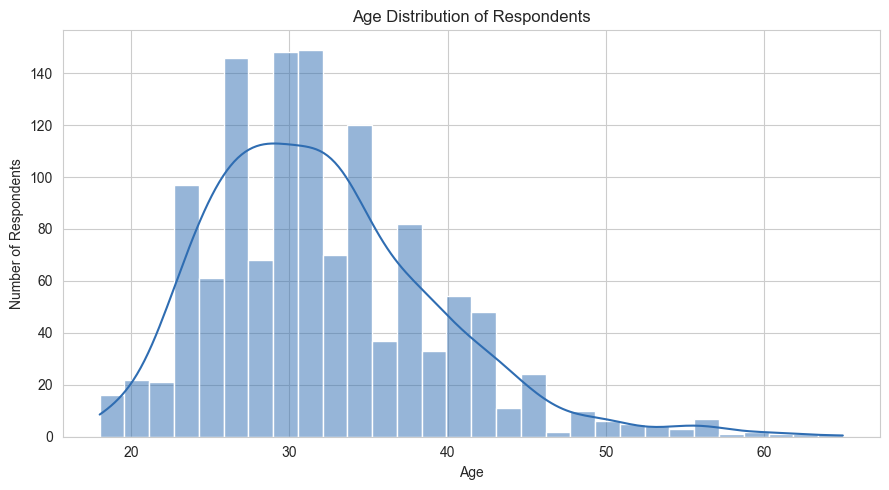

In [45]:
plt.figure(figsize=(9,5))

sns.histplot(
    df['Age'],
    bins=30,
    color='#2F6DB2',
    kde=True
)

plt.title('Age Distribution of Respondents')
plt.xlabel('Age')
plt.ylabel('Number of Respondents')

plt.tight_layout()
plt.show()


**Caption:** most respondents are in their late 20s to mid-30s, consistent with a working tech-industry population. 
The distribution is right-skewed with a long but thin tail toward older ages.

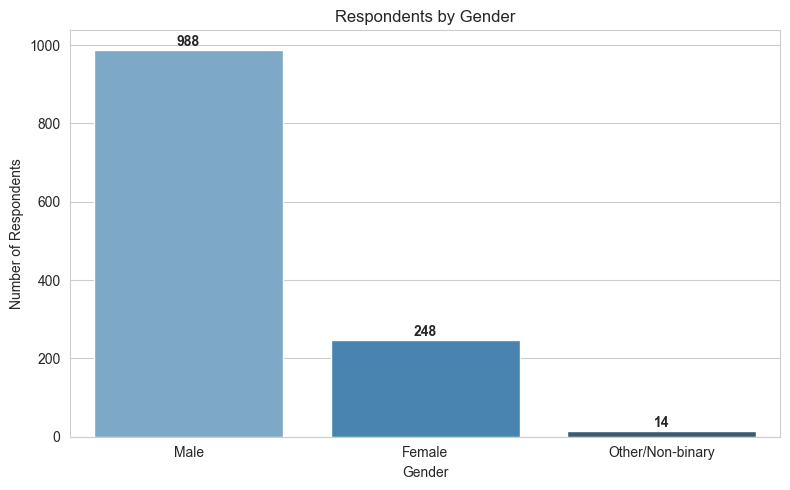

In [49]:
plt.figure(figsize=(8,5))

gender_counts = df['Gender_clean'].value_counts()

ax = sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values,
    palette='Blues_d'
)

for i, v in enumerate(gender_counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.title('Respondents by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Respondents')

plt.tight_layout()
plt.show()

**Caption:** the sample is heavily male (79%), consistent with tech industry demographics at the time of this 2014 survey. 
This imbalance means findings about smaller groups (Female, Other/Non-binary) come from proportionally fewer responses and 
should be read with that in mind.

Overall treatment rate: 50.5%


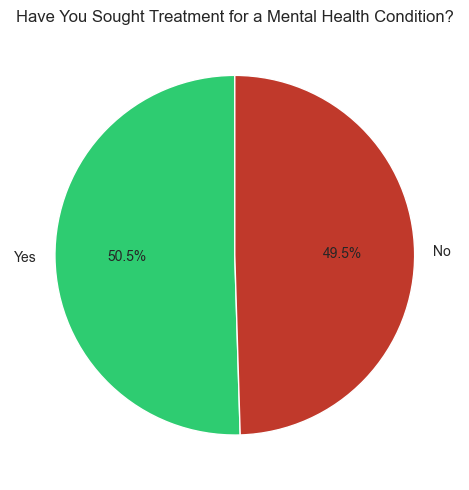

In [50]:
treatment_rate = (df['treatment']=='Yes').mean()*100
print(f'Overall treatment rate: {treatment_rate:.1f}%')

plt.figure(figsize=(6,5))
counts = df['treatment'].value_counts()
colors = ['#2ecc71','#c0392b']
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Have You Sought Treatment for a Mental Health Condition?')
plt.tight_layout()
plt.show()

**Caption:** just over half of respondents (50.6%) have sought treatment for a mental health condition — a striking figure that underlines 
how common this is in the tech workforce, and why employer support matters.

### 2.2 Does Treatment-Seeking Vary by Geographic Location?

In [51]:
df['treated'] = (df['treatment']=='Yes').astype(int)

country_rates = df.groupby('Country')['treated'].agg(['mean','count'])
country_rates = country_rates[country_rates['count'] >= 15].sort_values('mean', ascending=False)
country_rates['mean'] = country_rates['mean']*100
country_rates

,mean,count
Country,,
Australia,61.904762,21
United States,54.630872,745
Canada,51.388889,72
United Kingdom,50.000000,184
Ireland,48.148148,27
Germany,46.666667,45
Netherlands,33.333333,27


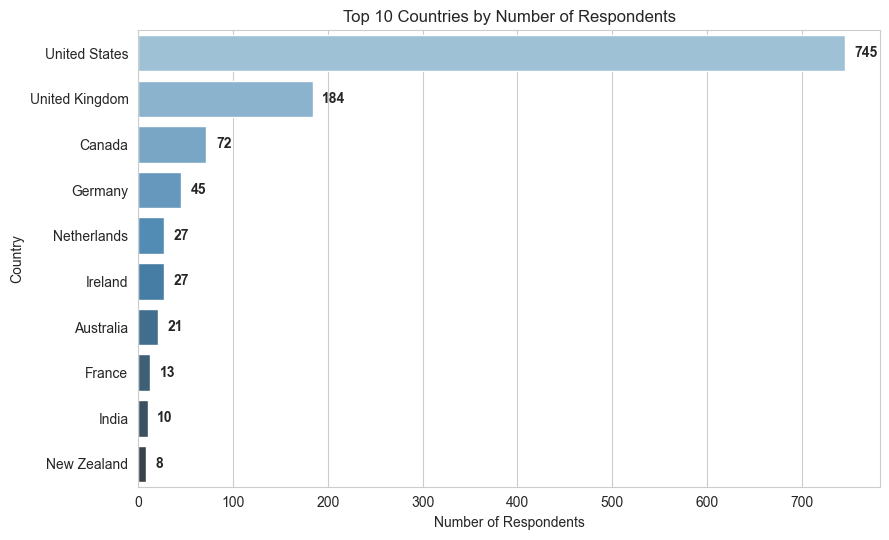

In [53]:
country_counts = df['Country'].value_counts().head(10)

plt.figure(figsize=(9,5.5))

ax = sns.barplot(
    x=country_counts.values,
    y=country_counts.index,
    palette='Blues_d'
)

for i, v in enumerate(country_counts.values):
    ax.text(v + 10, i, str(v), va='center', fontweight='bold')

plt.title('Top 10 Countries by Number of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

In [55]:
us_df = df[df['Country'] == 'United States'].copy()

state_treatment = pd.crosstab(
    us_df['state'],
    us_df['treatment'],
    normalize='index'
) * 100

state_treatment.head()

treatment,No,Yes
state,,
AL,14.285714,85.714286
AZ,14.285714,85.714286
CA,37.681159,62.318841
CO,55.555556,44.444444
CT,50.000000,50.000000


In [56]:
state_counts = us_df['state'].value_counts()

state_counts.head(20)

state
CA    138
WA     70
NY     56
TN     45
TX     44
PA     29
OR     29
IL     28
OH     27
IN     26
MI     22
MN     20
MA     20
FL     15
NC     14
VA     14
GA     12
WI     12
MO     12
UT     10
Name: count, dtype: int64

In [57]:
states_20plus = state_counts[state_counts >= 20].index

state_treatment_20plus = state_treatment.loc[states_20plus]

state_summary = pd.DataFrame({
    'Respondents': state_counts[states_20plus],
    'Treatment_Rate': state_treatment_20plus['Yes']
})

state_summary.sort_values('Treatment_Rate', ascending=False)

,Respondents,Treatment_Rate
state,,
OH,27,70.370370
IL,28,67.857143
CA,138,62.318841
MN,20,60.000000
OR,29,58.620690
WA,70,58.571429
TX,44,56.818182
NY,56,53.571429
MA,20,50.000000


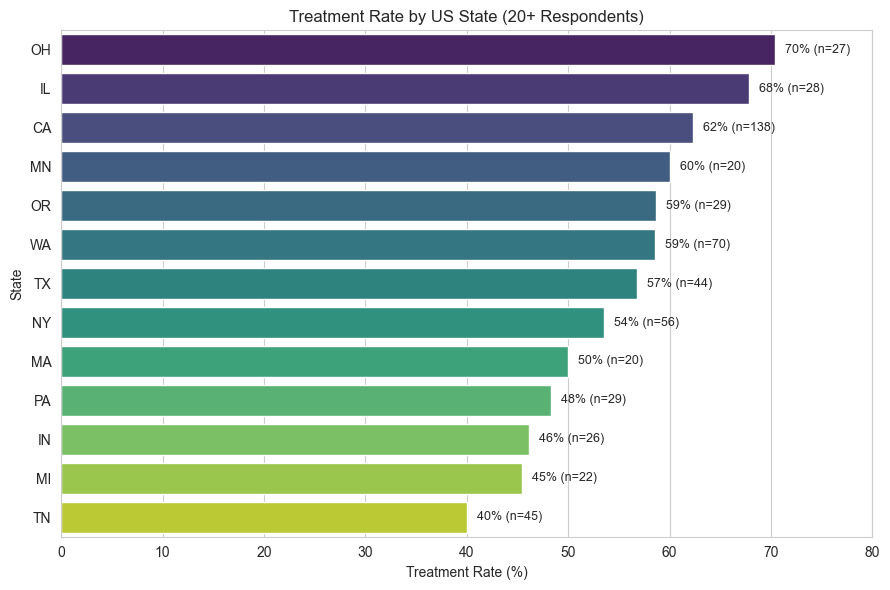

In [58]:
plot_data = state_summary.sort_values('Treatment_Rate', ascending=False)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=plot_data['Treatment_Rate'],
    y=plot_data.index,
    palette='viridis'
)

for i, (rate, n) in enumerate(
    zip(plot_data['Treatment_Rate'], plot_data['Respondents'])
):
    ax.text(rate + 1, i, f'{rate:.0f}% (n={n})', va='center', fontsize=9)

plt.title('Treatment Rate by US State (20+ Respondents)')
plt.xlabel('Treatment Rate (%)')
plt.ylabel('State')
plt.xlim(0, 80)

plt.tight_layout()
plt.show()

**Caption:** even within the US, treatment rates range widely — from 40% in Tennessee to 70% in Ohio. With sample sizes of 15–140 per state,
some of this spread is likely noise, but the range is wide enough that state-level culture or healthcare access may play a role worth 
investigating with more data.

### 2.3 Workplace Factors & Treatment-Seeking

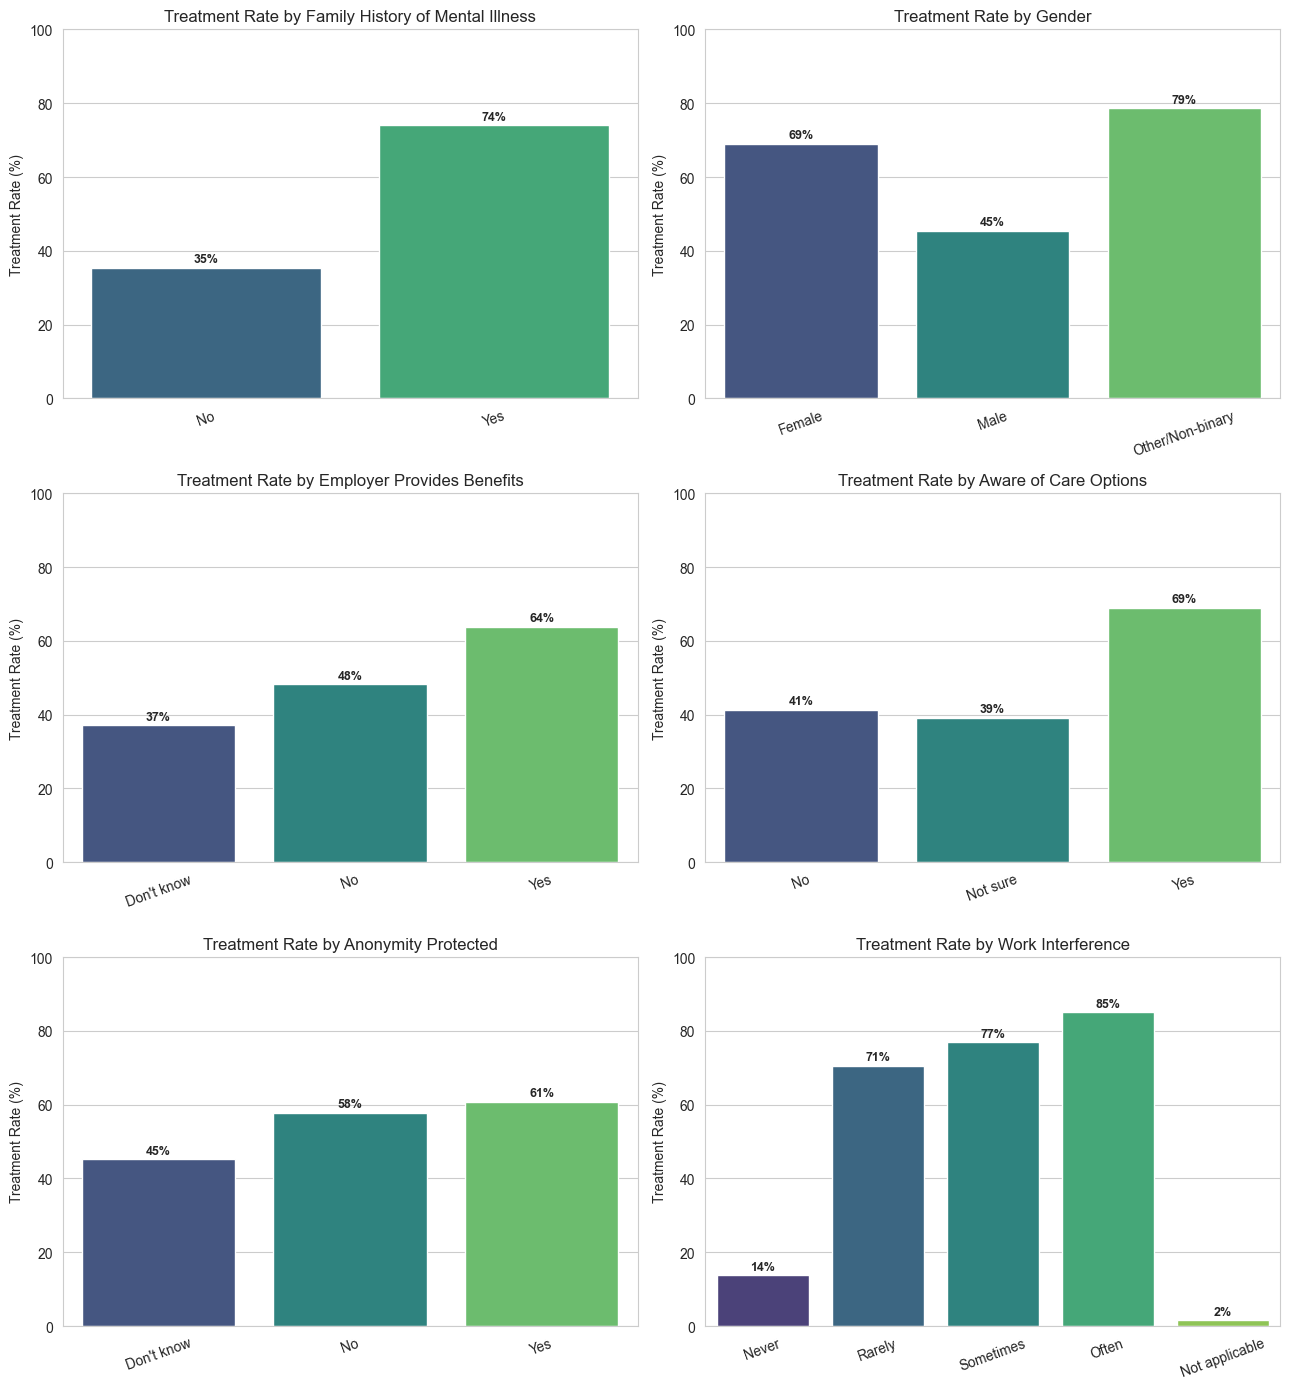

In [65]:
factors = [
    'family_history',
    'Gender_clean',
    'benefits',
    'care_options',
    'anonymity',
    'work_interfere'
]

titles = [
    'Family History of Mental Illness',
    'Gender',
    'Employer Provides Benefits',
    'Aware of Care Options',
    'Anonymity Protected',
    'Work Interference'
]

fig, axes = plt.subplots(3, 2, figsize=(13, 14))
axes = axes.flatten()

for ax, factor, title in zip(axes, factors, titles):

    rates = df.groupby(factor)['treatment'].apply(
        lambda x: (x == 'Yes').mean() * 100
    )

    if factor == 'work_interfere':
        cat_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Not applicable']
        rates = rates.reindex(
            [c for c in cat_order if c in rates.index]
        )

    sns.barplot(
        x=rates.index,
        y=rates.values,
        palette='viridis',
        ax=ax
    )

    for i, v in enumerate(rates.values):
        ax.text(
            i, v + 1.5,
            f'{v:.0f}%',
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

    ax.set_title(f'Treatment Rate by {title}')
    ax.set_ylabel('Treatment Rate (%)')
    ax.set_xlabel('')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Caption:** several workplace and personal factors show a clear relationship with treatment-seeking:
- **Family history** is the single strongest split: 74% of those with a family history of mental illness have sought treatment, versus 35% without.
- **Gender** differs sharply: Female (69%) and Other/Non-binary (79%) respondents report seeking treatment far more often than Male respondents (45%).
- **Benefits** and **awareness of care options** both are associated with higher treatment rates— treatment rate jumps from 37–41% among those who don't know what's covered to 64–69% 
among those who do. Notably, simply *knowing* about care options tracks almost as strongly as having benefits at all.
- **Anonymity protection** shows a smaller but consistent lift (45% "don't know" vs 61% "yes").
- **Work interference** shows the strongest gradient of all — from 14% (never interferes) to 85% (often interferes) — though this is partly circular:
someone who says their condition "often" interferes with work has likely already recognised they have one, which naturally correlates with having 
sought treatment.

In [67]:
factors = [
    'Gender_clean',
    'benefits',
    'care_options',
    'anonymity'
]

for factor in factors:
    print(f'\n--- {factor} ---')
    
    rates = df.groupby(factor)['treatment'].apply(
        lambda x: (x == 'Yes').mean() * 100
    )
    
    print(rates.round(1))


--- Gender_clean ---
Gender_clean
Female              69.0
Male                45.4
Other/Non-binary    78.6
Name: treatment, dtype: float64

--- benefits ---
benefits
Don't know    37.1
No            48.2
Yes           63.8
Name: treatment, dtype: float64

--- care_options ---
care_options
No          41.3
Not sure    39.1
Yes         69.0
Name: treatment, dtype: float64

--- anonymity ---
anonymity
Don't know    45.2
No            57.8
Yes           60.8
Name: treatment, dtype: float64


In [68]:
for factor in factors:
    print(f'\n--- {factor} ---')
    print(df[factor].value_counts())


--- Gender_clean ---
Gender_clean
Male                988
Female              248
Other/Non-binary     14
Name: count, dtype: int64

--- benefits ---
benefits
Yes           472
Don't know    407
No            371
Name: count, dtype: int64

--- care_options ---
care_options
No          499
Yes         439
Not sure    312
Name: count, dtype: int64

--- anonymity ---
anonymity
Don't know    814
Yes           372
No             64
Name: count, dtype: int64


In [69]:
print(df[['treatment', 'treated']].head())

  treatment  treated
0       Yes        1
1        No        0
2        No        0
3       Yes        1
4        No        0


In [70]:
summary_factors = {
    'Family History': df.groupby('family_history')['treatment'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ),
    'Gender': df.groupby('Gender_clean')['treatment'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ),
    'Benefits': df.groupby('benefits')['treatment'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ),
    'Care Options': df.groupby('care_options')['treatment'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ),
    'Anonymity': df.groupby('anonymity')['treatment'].apply(
        lambda x: (x == 'Yes').mean() * 100
    )
}

for factor, rates in summary_factors.items():
    print(f'\n{factor}')
    print(rates.round(1))


Family History
family_history
No     35.4
Yes    74.0
Name: treatment, dtype: float64

Gender
Gender_clean
Female              69.0
Male                45.4
Other/Non-binary    78.6
Name: treatment, dtype: float64

Benefits
benefits
Don't know    37.1
No            48.2
Yes           63.8
Name: treatment, dtype: float64

Care Options
care_options
No          41.3
Not sure    39.1
Yes         69.0
Name: treatment, dtype: float64

Anonymity
anonymity
Don't know    45.2
No            57.8
Yes           60.8
Name: treatment, dtype: float64


## Business Question 2 — Which factors are most strongly associated with treatment-seeking?

The analysis shows clear differences in treatment-seeking across several personal and workplace-related factors.

- **Family history:** 74.0% of respondents with a family history of mental illness reported seeking treatment, compared with 35.4% among those without a family history.

- **Work interference:** Treatment-seeking increased from 13.7% among respondents who reported that mental health never interfered with work to 85.0% among those reporting that it often interfered.

- **Care options:** 69.0% of respondents who knew about available care options reported seeking treatment, compared with 41.3% among those who answered "No."

- **Benefits:** Treatment-seeking was 63.8% among respondents whose employer provided mental health benefits, compared with 48.2% among those whose employer did not.

- **Gender:** Female respondents reported a higher treatment rate than male respondents (69.0% vs. 45.4%). The Other/Non-binary group had a higher rate (78.6%), but the group was small (n=14), so this result should be interpreted cautiously.

- **Anonymity:** The relationship was weaker, with treatment rates of 60.8% among respondents who answered "Yes" and 45.2% among those who answered "Don't know."

### Key Finding

Overall, **family history and work interference show the clearest differences in treatment-seeking**, while awareness of care options and employer benefits also show meaningful associations.

> **Note:** These findings represent associations within this self-reported survey sample and do not establish causation. They should not be interpreted as evidence that any individual factor directly causes someone to seek treatment.

In [72]:
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']

size_rates = df.groupby('no_employees')['treatment'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reindex(order)

print(size_rates.round(1))

no_employees
1-5               55.7
6-25              43.9
26-100            51.7
100-500           54.3
500-1000          44.1
More than 1000    52.0
Name: treatment, dtype: float64


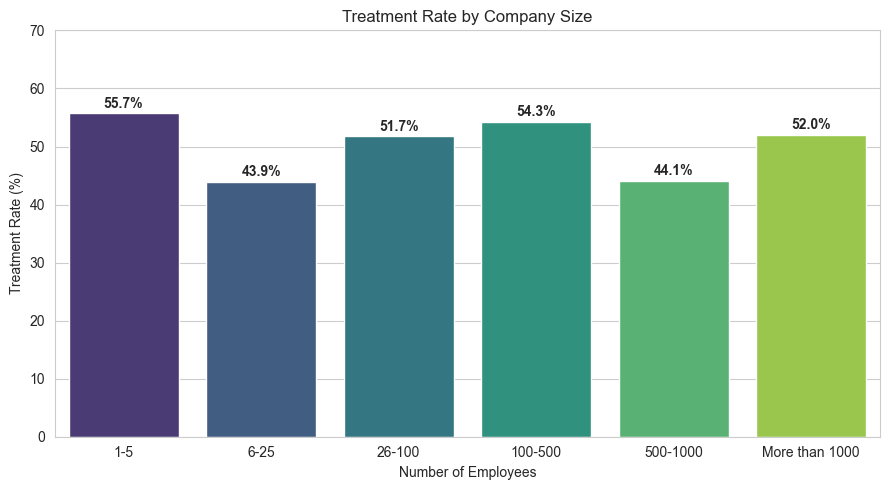

In [73]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    x=size_rates.index,
    y=size_rates.values,
    palette='viridis'
)

for i, v in enumerate(size_rates.values):
    ax.text(
        i, v + 1,
        f'{v:.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.title('Treatment Rate by Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('Treatment Rate (%)')
plt.ylim(0, 70)

plt.tight_layout()
plt.show()

In [74]:
company_size_counts = df['no_employees'].value_counts().reindex(order)

print(company_size_counts)

no_employees
1-5               158
6-25              289
26-100            288
100-500           175
500-1000           59
More than 1000    281
Name: count, dtype: int64


In [75]:
wellness_treatment = pd.crosstab(
    df['wellness_program'],
    df['treatment'],
    normalize='index'
) * 100

print(wellness_treatment.round(1))

treatment           No   Yes
wellness_program            
Don't know        57.0  43.0
No                50.2  49.8
Yes               41.0  59.0


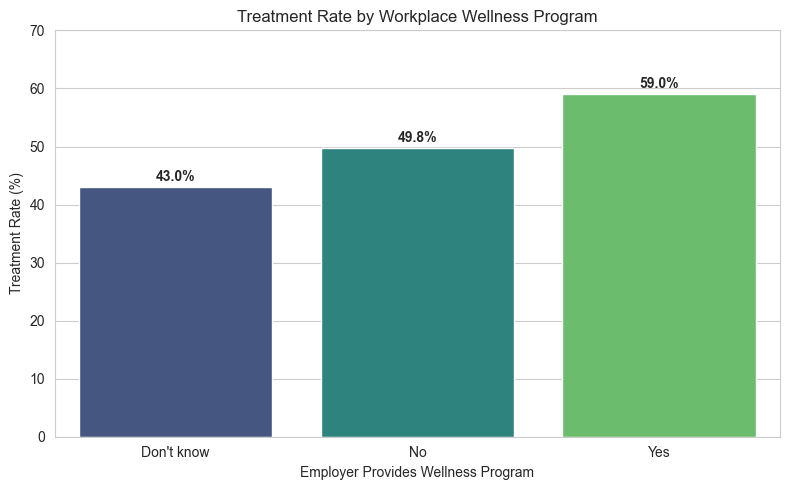

In [76]:
plt.figure(figsize=(8,5))

wellness_rates = df.groupby('wellness_program')['treatment'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

ax = sns.barplot(
    x=wellness_rates.index,
    y=wellness_rates.values,
    palette='viridis'
)

for i, v in enumerate(wellness_rates.values):
    ax.text(
        i, v + 1,
        f'{v:.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.title('Treatment Rate by Workplace Wellness Program')
plt.xlabel('Employer Provides Wellness Program')
plt.ylabel('Treatment Rate (%)')
plt.ylim(0, 70)

plt.tight_layout()
plt.show()

In [77]:
df['wellness_program'].value_counts()

wellness_program
No            837
Yes           227
Don't know    186
Name: count, dtype: int64

## Business Question 3 — How do workplace support factors relate to treatment-seeking?

The analysis shows that several workplace support factors are associated with differences in reported treatment-seeking.

- **Mental health benefits:** Treatment-seeking was 63.8% among respondents whose employer provided mental health benefits, compared with 48.2% among those whose employer did not and 37.1% among those who did not know.

- **Care options:** Respondents who knew that mental health care options were available had a higher treatment rate of 69.0%, compared with 41.3% among those who answered "No" and 39.1% among those who were "Not sure."

- **Anonymity:** Treatment rates were 60.8% among respondents who reported that anonymity was protected, compared with 45.2% among those who did not know. The "No" group had a similar rate of 57.8%, but it was relatively small (n=64).

- **Wellness programs:** Treatment-seeking was 59.0% among respondents whose employer had discussed mental health through a wellness program, compared with 49.8% where no such program was reported and 43.0% among those who did not know.

- **Company size:** Treatment rates ranged from 43.9% to 55.7% across company-size categories, with no clear increasing or decreasing pattern. The 500–1000 employee group should be interpreted cautiously because it had only 59 respondents.

### Key Finding

Overall, **awareness and availability of workplace mental health support show noticeable associations with treatment-seeking**, particularly mental health benefits and knowledge of available care options. Wellness programs also show a positive association, while company size alone does not show a clear pattern in this survey.

> **Note:** These findings represent associations within this self-reported survey sample and do not establish that workplace support factors directly cause employees to seek treatment.

# Stage 3 — Summary & Recommendations

## 3.1 Key Findings

- **50.5%** of respondents reported seeking treatment for a mental health condition.
- Treatment rates varied by geography, with differences across countries and US states.
- **Family history** showed a strong association with treatment-seeking: **74.0%** with a family history vs **35.4%** without.
- Treatment-seeking increased with reported **work interference**, from **13.7%** for "Never" to **85.0%** for "Often".
- Respondents aware of available **care options** had a higher treatment rate (**69.0%**) than those who answered "No" (**41.3%**).
- **Company size** showed no clear pattern, while wellness programs showed a moderate association with treatment-seeking.

## 3.2 Business Recommendations

1. **Improve awareness:** Clearly communicate available mental health care options and benefits.
2. **Strengthen support:** Continue workplace wellness and mental health awareness initiatives.
3. **Train managers:** Encourage supportive, non-stigmatising responses to employees experiencing difficulties.
4. **Focus on accessibility:** Make mental health resources easy to find and access regardless of company size.

> These findings represent associations within the survey sample and do not establish causation.